In [1]:
using Base.Threads
println( "Number of threads: ", nthreads() )

include( "../args.jl" )
include( "../model.jl" )

Number of threads: 24
Loaded network.jl class file.
Loaded model.jl class file.


In [2]:
# Simulation length/time scale.
ξ = 0.1;  δt = Δt
scale = Scale( 1.0, ξ )

# Default simulation parameters.
ρ = 0.1;  γ = 0.1;  τ = 75.0;  s = 100.0
params = Params(; ρ=ρ, γ=γ, τ=τ, s=s, ξ=ξ )

# Non-dimensional parameter variable.
nondim = Nondim( params; scale=scale )

Nondim(0.1, 0.010000000000000002, 0.010000000000000002, 0.0, 750.0, 1.0, 0.5, 0.0, 0.5, 0.25, 5.623413251903491, 1.0, 0.7853981633974483, LogNormal{Float64}(μ=-0.11157177565710488, σ=0.47238072707743883), Truncated(Laplace{Float64}(μ=0.0, θ=0.5); lower=-3.141592653589793, upper=3.141592653589793))

In [3]:
# Varying system parameters.
μ = 1.0
N = defInt( 100 )
L = √(N/μ)

# Data folder name.
case = "../data/results/case-0/"
folder = case*"N-$(N)/mu-$(round( μ, digits=3 ))_xi-$(round( ξ, digits=5 ))/"

"../data/results/case-0/N-100/mu-1.0_xi-0.1/"

In [4]:
# Run simulation under each environment parameter.
T = τ/scale.T;  M = 1
Nt = round( defInt, T/δt );  tlist = 1:Nt
nt = round( defInt, 1/(2*δt*scale.T) );  tsave = Set( 1:nt:Nt );

In [5]:
# Initialize data variables.
xdata = [Matrix{defFloat}( undef, length( tsave ) + 1, 3 ) for _ ∈ 1:M]
ẑlist = Vector{State}( undef, M )

# Interaction data variables.
Âlist = Vector{SparseMatrixCSC{defInt,defInt}}( undef, M )

# Initialize activation order variable.
hdata = [[1;fill( defInt( -1 ), N-1 )] for _ ∈ 1:M]
Tdata = [[0.0;fill( defFloat( -1 ), N-1 )] for _ ∈ 1:M];

In [6]:
# Bipartite graph to check.
φ1 = 0;  φ2 = 1

# Run simulation.
@threads for m ∈ 1:M
    # Initialize agent states.
    z = State( N, L; A=1 )
    ẑ = copystate( z )

    # Initialize adjacency and saved state.
    A = proximity( N, L, r, nondim.α, z.x, z.y, z.θ )
    Â = spzeros( defInt, N, N )

    # Initialize saved states.
    xdata[m][1,:] = statecomposition( N, z )

    # Run simulation.
    t̂ = 2;  h = 2
    for t ∈ tlist[1:end]
        # Update the adjacency matrix.
        A = proximity( N, L, r, nondim.α, z.x, z.y, z.θ )

        # Step simulation.
        step!( N, L, nondim, z, ẑ; δt=δt, A=A )

        # Check if an agent transitioned to the active state.
        iφ = transitioned( z, ẑ; φ=φ1 )
        if any( iφ )
            # Save any active agent connections.
            Ât = dirconditionaladj( N, A, z; φ1=φ1, φ2=φ2 )
            Â[:,iφ] = Ât[:,iφ]

            # Add to activation order list.
            hdata[m][iφ] .= h;  h += 1
            Tdata[m][iφ] .= t*δt
        end

        # Save the state composition.
        t ∈ tsave && (xdata[m][t̂,:] = statecomposition( N, z );  t̂ += 1)

        # Swap contents.
        tmp = z;  z = ẑ;  ẑ = tmp
    end

    # Neglect first agent if there was no activity burst.
    (maximum( hdata[m] ) == 1) && (hdata[m][1] = -1)

    # Save last simulation state.
    Âlist[m] = Â
    ẑlist[m] = z
end

In [10]:
# Collect indeces of agents who were activated.
hlist = vcat( hdata... )
ilist = hlist .== -1

# Extract the depth of each node in the activation tree.
ddata = depthN.( N, Âlist; f=minimum )
d̂data = depthN.( N, Âlist; f=maximum )

# Compute the node-depth distribution.
dlist = vcat( d̂data... );  dlist[ilist] .= 0;

In [7]:
# Plot the mean activity deries for each duration value.
plt = plot( size=(300,200), xformatter=:plain, margin=10pt, dpi=600 )

for m ∈ 1:M
    alist = xdata[m][:,1]
    alpha = m == 10 ? 1 : 1/10
    plot!( plt, 0:1/2:T, alist; color=:black, alpha=alpha, lw=2, label="" )
end

plot!( plt; xlims=(0,T), xlabel="time, "*L"t" )
plot!( plt; ylims=(0,1), ylabel="proportion of\nants active, "*L"a" )

┌ Warning: Keyword argument `orientation` is deprecated.
│ Please use `permute` instead.
└ @ Plots /home/michaelnaps/.julia/packages/Plots/MR7sb/src/args.jl:1552


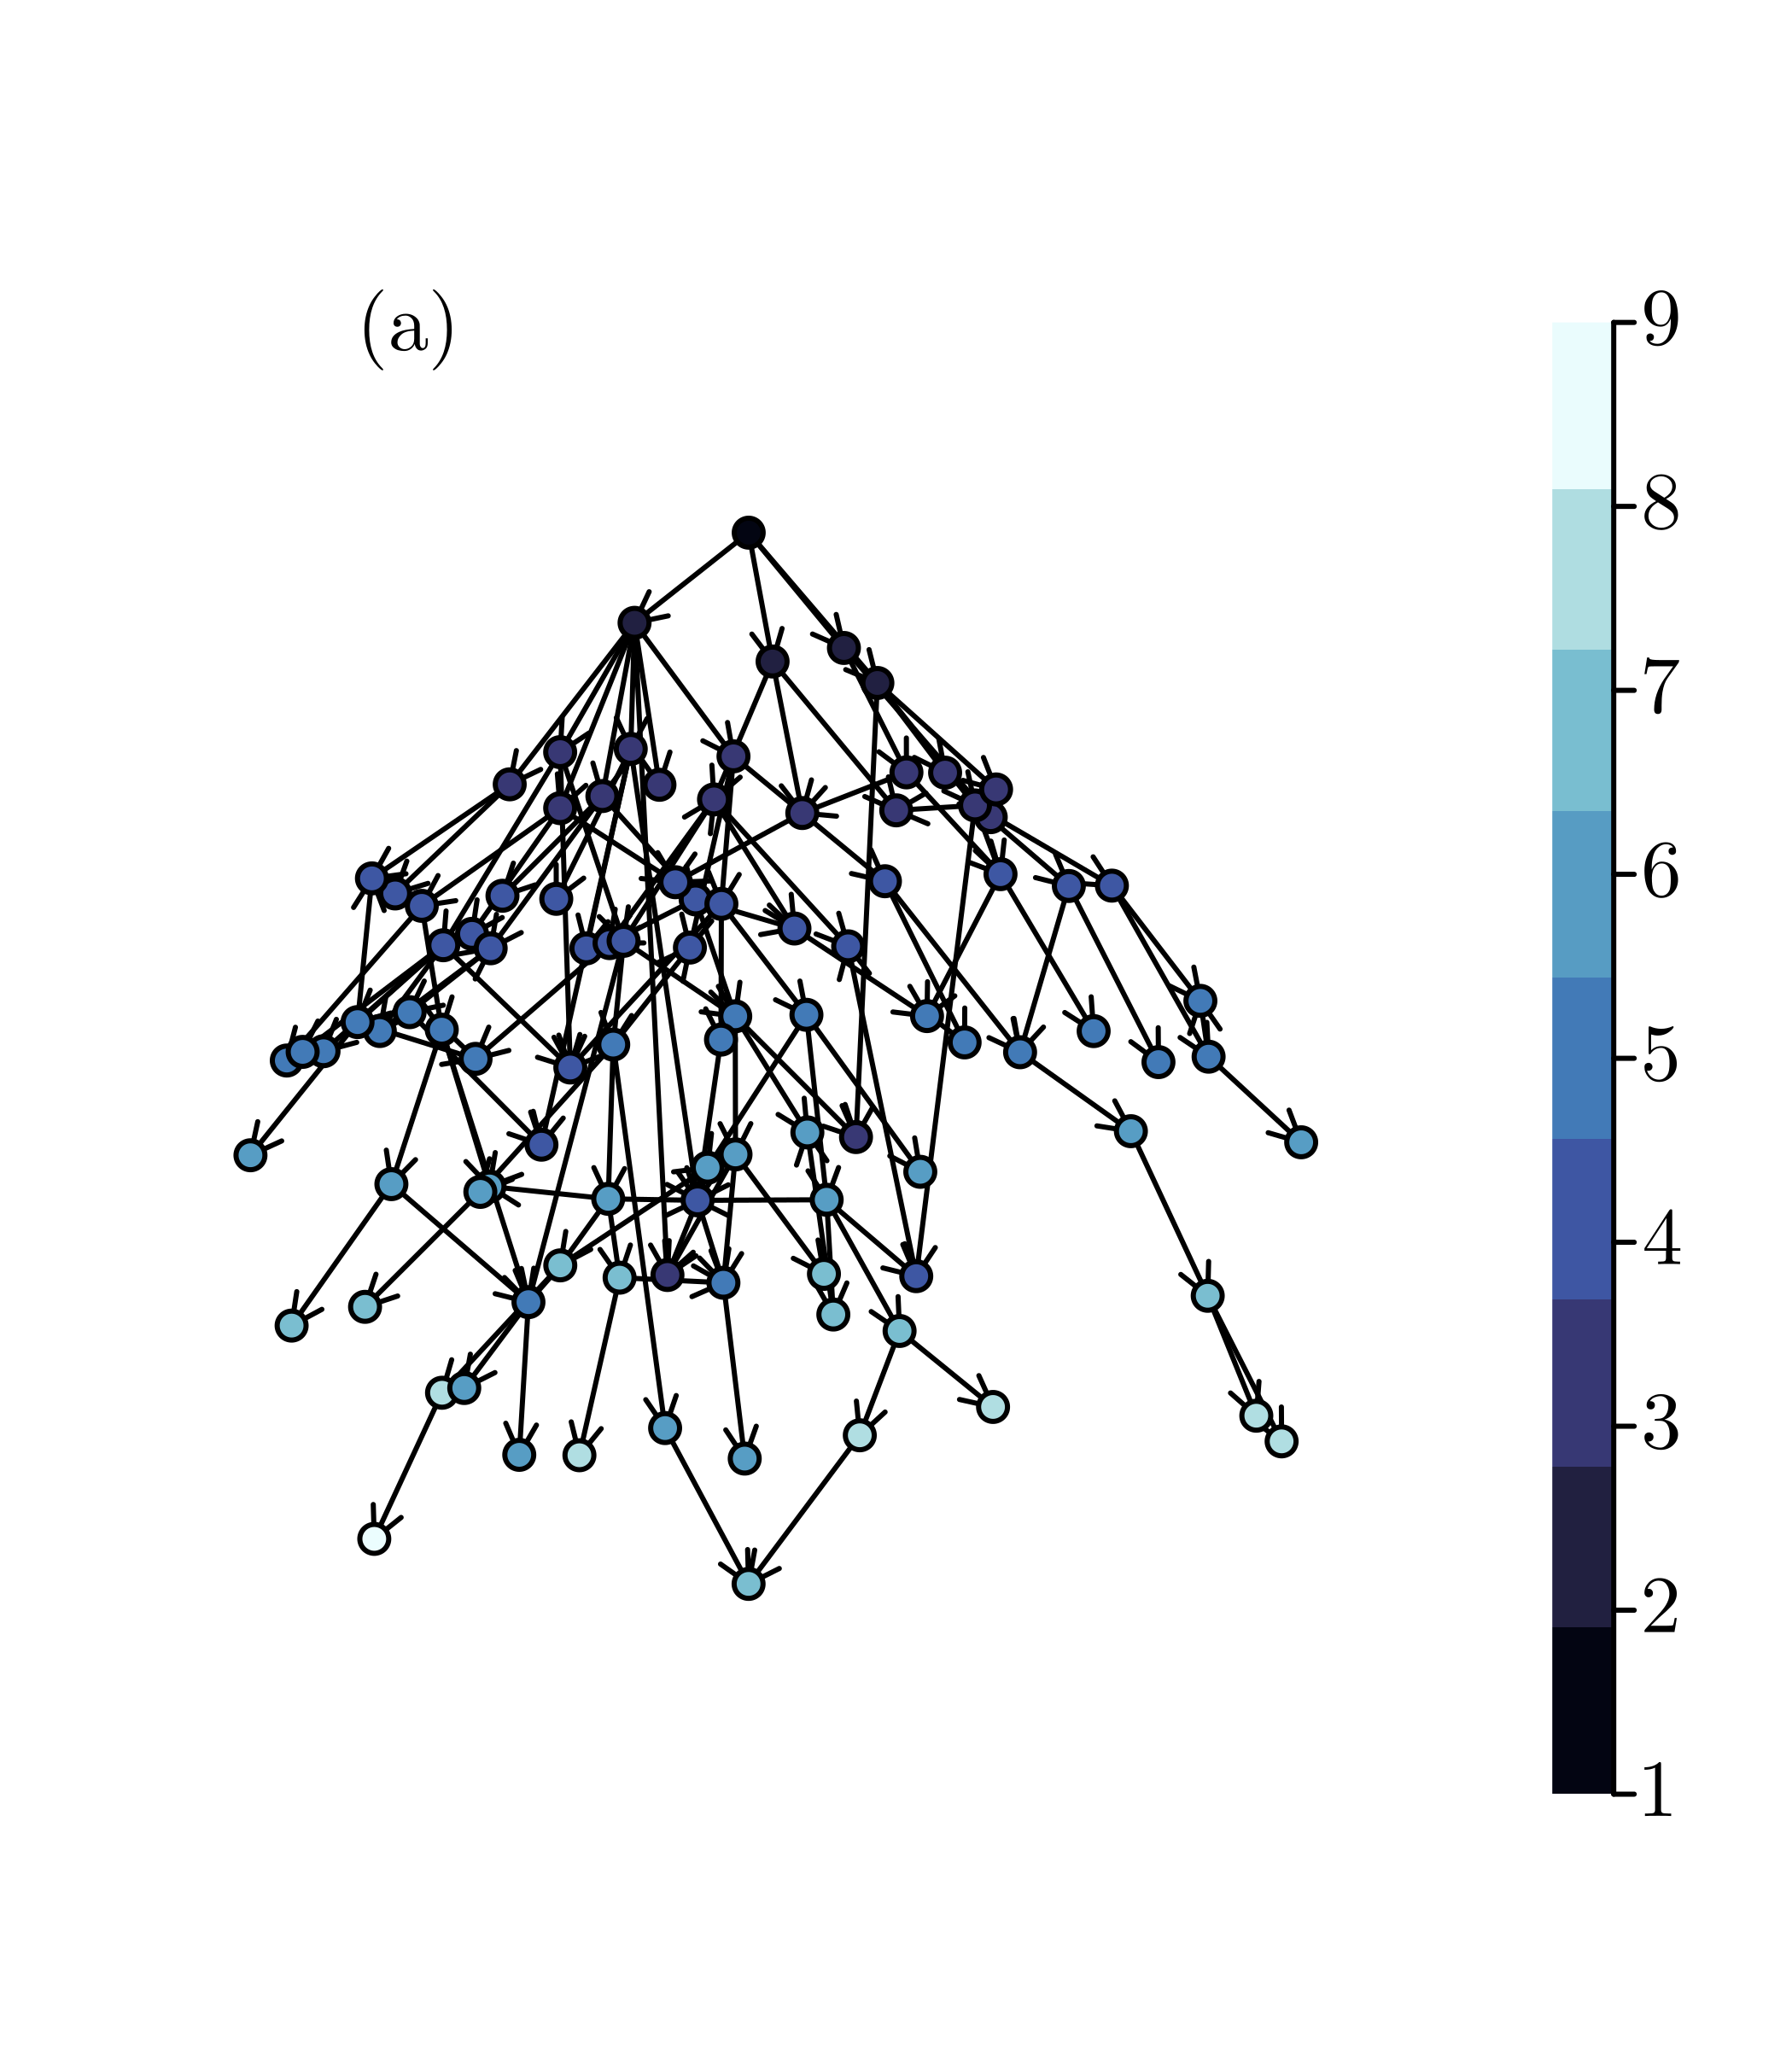

In [11]:
using Graphs, GraphRecipes

m = 1
A = Âlist[m];  dlist = ddata[m]
G = SimpleDiGraph( A )

# Initialize plot variable.
plt = plot( size=(350,400), xformatter=:plain, margin=10pt, dpi=600 )
plot!( plt; top_margin=0pt, left_margin=0pt, bottom_margin=5pt )

# Plot an example activation graph.
palette = cgrad( :ice, maximum( dlist ), categorical=true )
graphplot!( plt, G;
    marker=:circ, markersize=0.125,
    nodecolor=palette[dlist], arrow=true,
    curves=false, method=:tree,
    orientation=:permute,
    aspect_ratio=:equal )

scatter!( plt, [NaN], [NaN]; zcolor=dlist, c=palette, colorbar_tickfont=font( 14, "Computer Modern" ) )

# xspan = 1/2;  yspan = 1/2+0.1
# plot!( plt; xlims=(-xspan,xspan), ylims=(-yspan,yspan) )

title!( plt, "(a)"; title_position=[1/4,1] )

# saveplot( plt, figurefolder*"activation-graph_N-$(N).png" )

In [9]:
# Save data.
if false
    if !isdir( folder )
        mkpath( folder )
    end

    writedlm( folder*"activation-order.txt", hdata )
    writedlm( folder*"activation-time.txt", Tdata )
    writedlm( folder*"outgoing-activations.txt", ndata )
    writedlm( folder*"incoming-activations.txt", n̂data )
    writedlm( folder*"tree-depth-min.txt", ddata )
    writedlm( folder*"tree-depth-max.txt", d̂data )
end